In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Kütüphaneleri (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Tüm kütüphaneler başarıyla yüklendi! ✅")

Tüm kütüphaneler başarıyla yüklendi! ✅


In [5]:
# Day 3'teki veri setimizi yüklüyoruz
df = pd.read_csv("students_data.csv")

# Sütun isimlerimizi kontrol edelim
print("Sütunlar:", df.columns.tolist())

# Missing (NaN) değerleri ortalama ile dolduruyoruz
df["Assignment_Score"] = df["Assignment_Score"].fillna(df["Assignment_Score"].mean())
df["Midterm_Score"] = df["Midterm_Score"].fillna(df["Midterm_Score"].mean())
df["Final_Score"] = df["Final_Score"].fillna(df["Final_Score"].mean())

# Genel ortalama hesabı
df["Overall_Score"] = (df["Assignment_Score"] + df["Midterm_Score"] + df["Final_Score"]) / 3

df.head()

Sütunlar: ['Student_Name', 'Age', 'Gender', 'Course', 'Attendance', 'Assignment_Score', 'Midterm_Score', 'Final_Score']


,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score,Overall_Score
0,Alice,24,Female,AI/ML,85.0,90.000000,80.0,85.0,85.000000
1,Bob,22,Male,Data Science,62.0,55.000000,60.0,58.0,57.666667
2,Charlie,21,Male,AI/ML,90.0,95.000000,88.0,92.0,91.666667
3,David,23,Male,Web Dev,45.0,50.000000,40.0,42.0,44.000000
4,Emma,26,Female,AI/ML,70.0,74.206897,65.0,60.0,66.402299


In [6]:
# Genel ortalaması 50 ve üzeri olanlar Pass (1), altı olanlar Fail (0)
df["Passed"] = (df["Overall_Score"] >= 50).astype(int)

# Geçti / Kaldı dağılımını görelim
print("Sınıf Dağılımı (1: Pass, 0: Fail):")
print(df["Passed"].value_counts())

Sınıf Dağılımı (1: Pass, 0: Fail):
Passed
1    26
0     4
Name: count, dtype: int64


In [8]:
# Modele vereceğimiz girdiler (Features)
X = df[["Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]]

# Modelin tahmin etmesini istediğimiz çıktı (Target)
y = df["Passed"]

print("Feature Matrisi Boyutu (X):", X.shape)
print("Target Vektörü Boyutu (y):", y.shape)

Feature Matrisi Boyutu (X): (30, 4)
Target Vektörü Boyutu (y): (30,)


In [9]:
# Verinin %80'ini eğitim (Train), %20'sini test için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim Verisi Sayısı: {len(X_train)}")
print(f"Test Verisi Sayısı: {len(X_test)}")

Eğitim Verisi Sayısı: 24
Test Verisi Sayısı: 6


In [10]:
# 1. Modeli Tanımla
model = LogisticRegression()

# 2. Modeli Eğit (Fit)
model.fit(X_train, y_train)

# 3. Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)

print("Tahminler başarıyla oluşturuldu! 🎯")

Tahminler başarıyla oluşturuldu! 🎯


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print(f"📊 Model Accuracy (Doğruluk Oranı): {accuracy * 100:.2f}%\n")
print("📋 Classification Report:")
print(classification_report(y_test, y_pred))

📊 Model Accuracy (Doğruluk Oranı): 100.00%

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



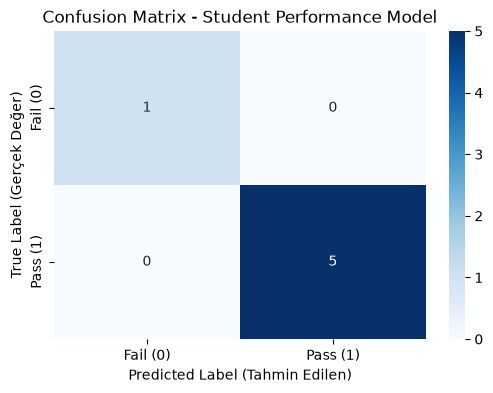

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Fail (0)", "Pass (1)"], 
            yticklabels=["Fail (0)", "Pass (1)"])
plt.xlabel("Predicted Label (Tahmin Edilen)")
plt.ylabel("True Label (Gerçek Değer)")
plt.title("Confusion Matrix - Student Performance Model")
plt.savefig("chart1_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\aysenur\AppData\Local\Temp\ipykernel_17076\241418947.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


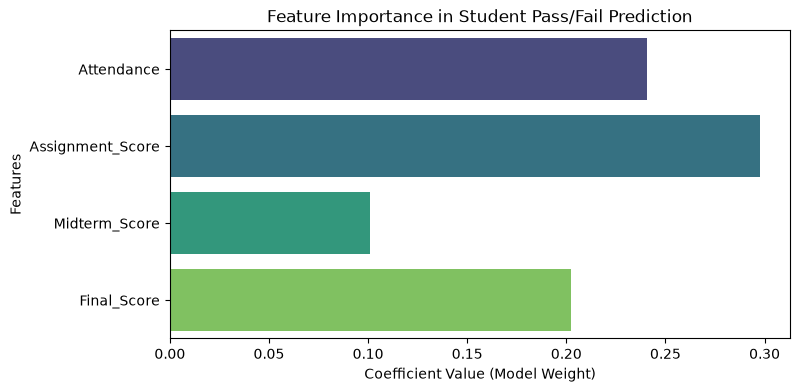

In [13]:
# Modelin hangi özelliğe ne kadar önem verdiğini (katsayılarını) görselleştiriyoruz
importance = model.coef_[0]
features = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importance, y=features, palette="viridis")
plt.title("Feature Importance in Student Pass/Fail Prediction")
plt.xlabel("Coefficient Value (Model Weight)")
plt.ylabel("Features")
plt.savefig("chart2_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()